<a href="https://colab.research.google.com/github/Noory6m/Lab2-IP/blob/main/Lab2_Digital_Image_Fundamentals_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

## Setup

In [3]:
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

In [4]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

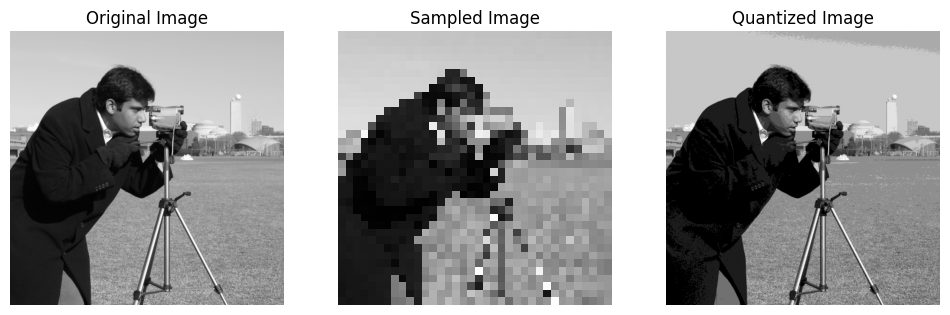

In [ ]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

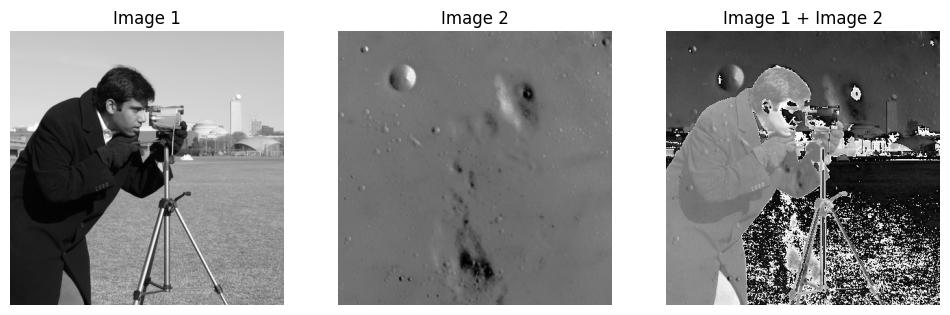

In [5]:
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
result_image = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

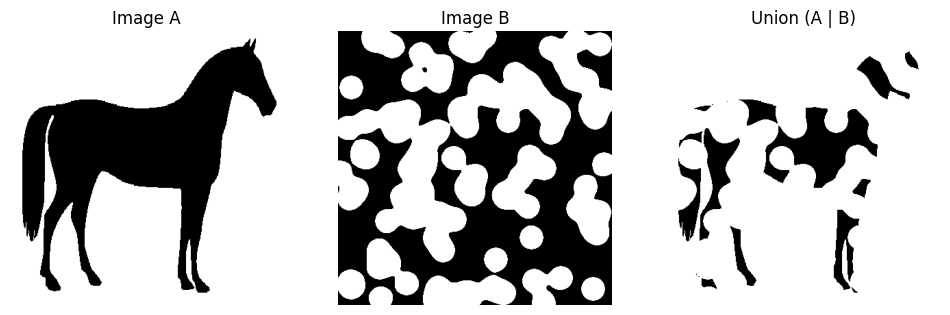

In [6]:
img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

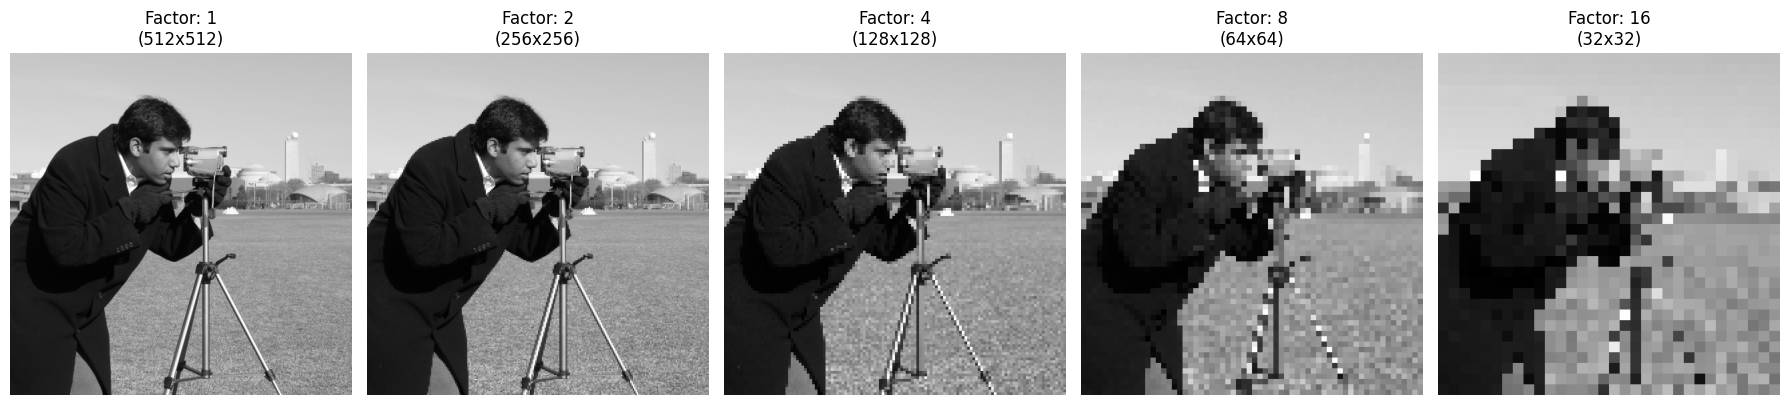

In [7]:
img = data.camera()
factors = [1, 2, 4, 8, 16]

fig, axes = plt.subplots(1, len(factors), figsize=(18, 4))

for ax, f in zip(axes, factors):
  h, w = img.shape
  # Downsample
  down = cv2.resize(
      img, (w // f, h // f), interpolation=cv2.INTER_NEAREST
  )  # Upsample back to show blockiness
  restored = cv2.resize(down, (w, h), interpolation=cv2.INTER_NEAREST)

  ax.imshow(restored, cmap='gray')
  ax.set_title(f'Factor: {f}\n({w // f}x{h // f})')
  ax.axis('off')

plt.tight_layout()
plt.show()

### 1b) Effect of quantization levels (intensity resolution)

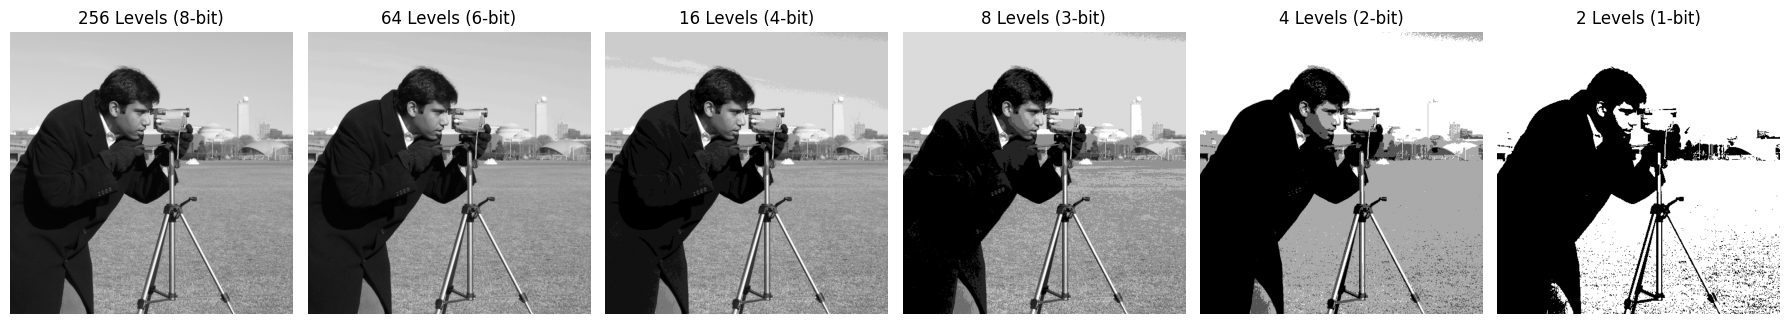

In [8]:
def quantize(image, levels):
  step = 256 // levels
  return (np.floor(image / step) * step).astype(np.uint8)


levels_list = [256, 64, 16, 8, 4, 2]
fig, axes = plt.subplots(1, len(levels_list), figsize=(18, 4))

for ax, lvl in zip(axes, levels_list):
  q_img = quantize(img, lvl)
  bits = int(np.log2(lvl))
  ax.imshow(q_img, cmap='gray')
  ax.set_title(f'{lvl} Levels ({bits}-bit)')
  ax.axis('off')

plt.tight_layout()
plt.show()

---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

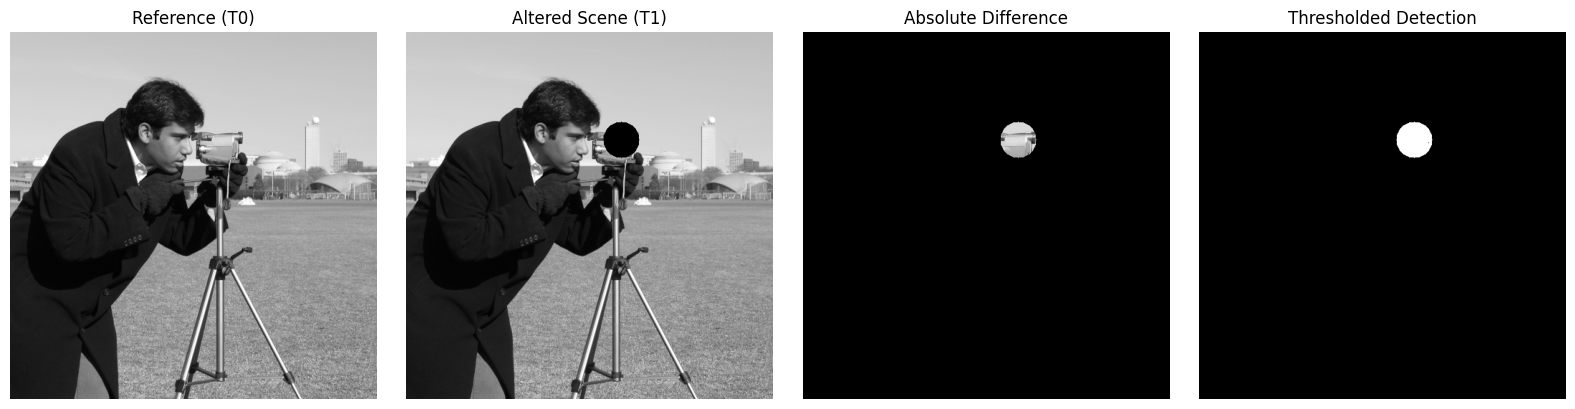

In [9]:
# Create an artificial defect/change in the scene
scene_t0 = data.camera().copy()
scene_t1 = scene_t0.copy()
cv2.circle(scene_t1, (300, 150), 25, 0, -1)  # Simulated object removal/addition

# Absolute difference highlights changes independent of sign
change_mask = cv2.absdiff(scene_t0, scene_t1)
_, thresholded_diff = cv2.threshold(change_mask, 30, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = [
    'Reference (T0)',
    'Altered Scene (T1)',
    'Absolute Difference',
    'Thresholded Detection',
]
imgs = [scene_t0, scene_t1, change_mask, thresholded_diff]

for ax, im, t in zip(axes, imgs, titles):
  ax.imshow(im, cmap='gray')
  ax.set_title(t)
  ax.axis('off')

plt.tight_layout()
plt.show()

### 2b) Add image with constant value 175

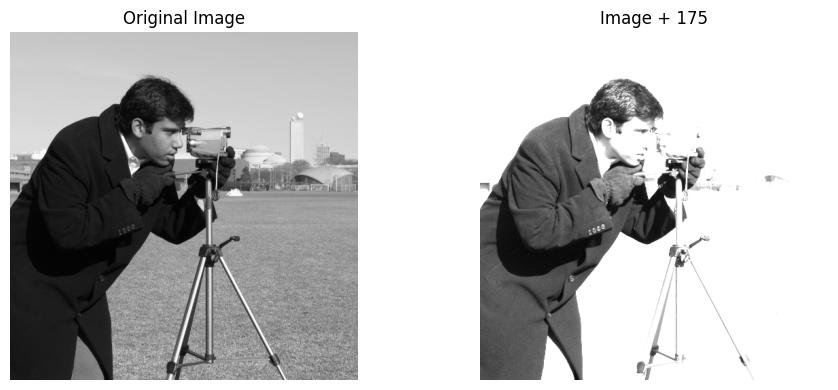

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import data

# Load a base grayscale image
img = data.camera()

# Method 1: Using cv2.add (saturating addition, clips at 255)
img_add_cv = cv2.add(img, 175)

# Method 2: Using NumPy with clipping (to prevent uint8 overflow wrap-around)
img_add_np = np.clip(img.astype(np.int16) + 175, 0, 255).astype(np.uint8)

# Plotting the results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_add_cv, cmap='gray')
plt.title('Image + 175')
plt.axis('off')

plt.tight_layout()
plt.show()

### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

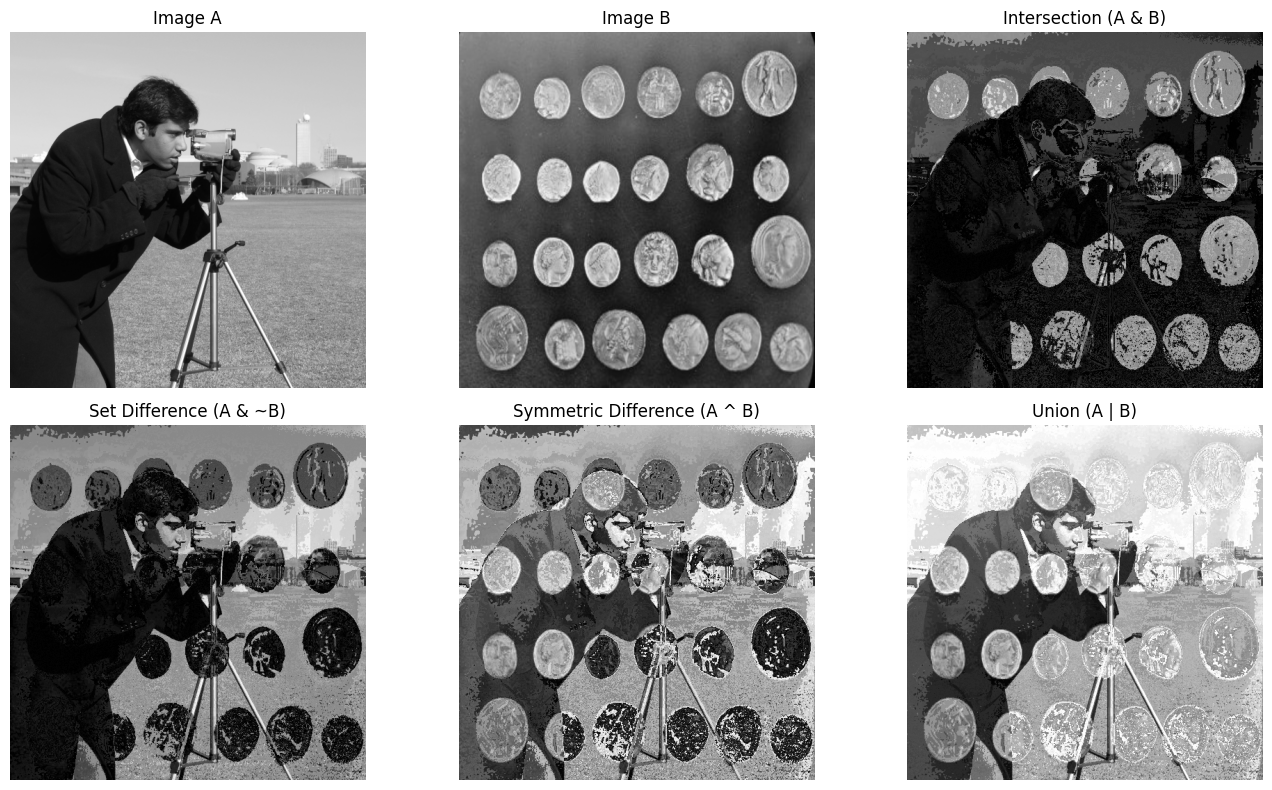

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import data

# Load or prepare two images of identical dimensions
A = data.camera()
B = cv2.resize(data.coins(), (A.shape[1], A.shape[0]))

# 2c) Intersection: A & B (bits set in both)
intersection = cv2.bitwise_and(A, B)

# 2d) Set difference: A & ~B (bits in A but not in B)
difference = cv2.bitwise_and(A, cv2.bitwise_not(B))

# 2e) Symmetric difference: A ^ B (bits in A or B but not both)
sym_difference = cv2.bitwise_xor(A, B)

# Union (extra): A | B (bits in either)
union = cv2.bitwise_or(A, B)

# Plotting the operations
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

titles = [
    'Image A',
    'Image B',
    'Intersection (A & B)',
    'Set Difference (A & ~B)',
    'Symmetric Difference (A ^ B)',
    'Union (A | B)',
]

images = [A, B, intersection, difference, sym_difference, union]

for ax, im, t in zip(axes.ravel(), images, titles):
  ax.imshow(im, cmap='gray')
  ax.set_title(t)
  ax.axis('off')

plt.tight_layout()
plt.show()